### What are embeddings?

### Think of embeddings as a way to translate words into language that computer understands - numbers 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.2, 0.2],
    "truck": [-0.45, 0.15]
}

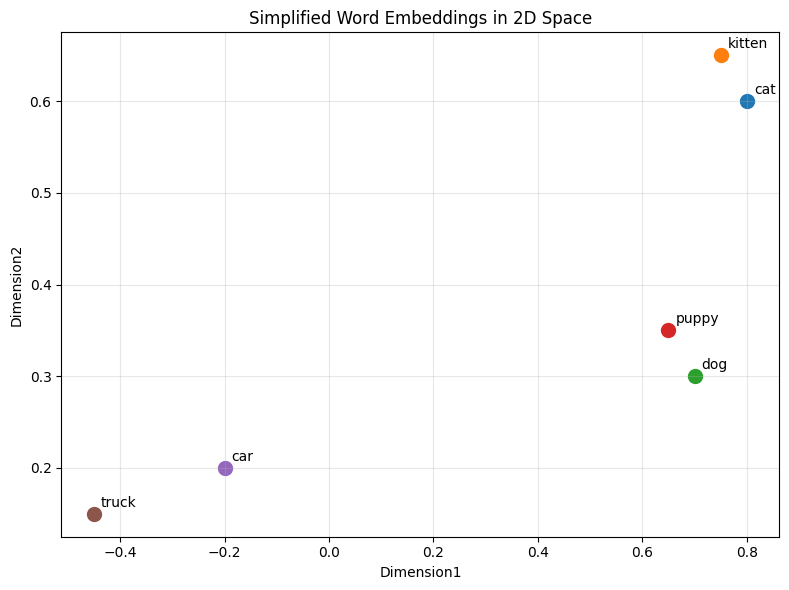

In [6]:
fig, ax = plt.subplots(figsize=(8,6))
for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5,5), textcoords='offset points')
ax.set_xlabel('Dimension1')
ax.set_ylabel('Dimension2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Measuring Cosine Similarity

In [7]:
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    return dot_product/(norm_a * norm_b)

    

In [9]:
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

result = cosine_similarity(cat_vector, car_vector)
print(result)

-0.43718588548916804


In [1]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
text = 'Hello, I am learning about embeddings!'
embed = embeddings.embed_query(text)
print(f"Original Text: {text}")
print(f"Length of embedding: {len(embed)}")
print(embed)


/Users/simransingh/Desktop/RAG Projects/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10589.08it/s]


Original Text: Hello, I am learning about embeddings!
Length of embedding: 384
[-0.018163282424211502, -0.09955167770385742, 0.013816109858453274, -0.008125923573970795, 0.014152180403470993, 0.0640648603439331, -0.006253357976675034, -0.0030178669840097427, 0.025287238880991936, -0.02019866183400154, 0.024329721927642822, 0.07435061782598495, 0.051177140325307846, 0.022038469091057777, -0.05830617994070053, 0.01526827272027731, 0.02358442358672619, 0.09455401450395584, -0.06508846580982208, 0.013296679593622684, -0.020497580990195274, -0.05690854787826538, 0.03030332177877426, -0.08365613967180252, 0.02659635618329048, -0.01523145753890276, -0.043615393340587616, 0.05398395657539368, 0.09025716781616211, -0.08893880248069763, 0.03964460641145706, -0.008835040964186192, -0.030343735590577126, 0.07425563037395477, -0.054099190980196, 0.11107998341321945, 0.03689985349774361, -0.008959794417023659, -0.06140244007110596, -0.0031433841213583946, 0.02195817418396473, 0.04220820590853691, -0

In [4]:
sentences = [
    "The cat sat on the mat",
    "The cat sat on the mat",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]

embedding_sentence = embeddings.embed_documents(sentences)
print(embedding_sentence[0])
print(embedding_sentence[1])

[0.1304018646478653, -0.011870156973600388, -0.028117036446928978, 0.05123863369226456, -0.05597447603940964, 0.030191605910658836, 0.030161278322339058, 0.024698300287127495, -0.01837052032351494, 0.05876682326197624, -0.024953166022896767, 0.06015419587492943, 0.039831653237342834, 0.033230483531951904, -0.06131136417388916, -0.049373142421245575, -0.05486348271369934, -0.0400761216878891, 0.05642916262149811, 0.03915659710764885, -0.03473711386322975, -0.013247736729681492, 0.031966205686330795, -0.06349916756153107, -0.06017861142754555, 0.0782344788312912, -0.028303874656558037, -0.04744279757142067, 0.04035934433341026, -0.0066309524700045586, -0.06674094498157501, -0.004191387910395861, -0.025311702862381935, 0.053341664373874664, 0.01742810569703579, -0.09792358428239822, 0.006061320658773184, -0.06524164229631424, 0.045572567731142044, 0.023641804233193398, 0.07658480852842331, -0.010264351963996887, -0.0040767602622509, -0.06232275813817978, 0.03370519354939461, 0.01866116374

In [7]:
from langchain_huggingface import HuggingFaceEmbeddings

models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },
    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },
    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

for name, info in models.items():
    print(f"Model Name: {name}")
    print(f"   Dimensions: {info['size']}")
    print(f"   Description: {info['description']}")
    print(f"   Use Case: {info['use_case']}\n")

Model Name: all-MiniLM-L6-v2
   Dimensions: 384
   Description: Fast and efficient, good quality
   Use Case: General purpose, real-time applications

Model Name: all-mpnet-base-v2
   Dimensions: 768
   Description: Best quality, slower than MiniLM
   Use Case: When quality matters more than speed

Model Name: all-MiniLM-L12-v2
   Dimensions: 384
   Description: Slightly better than L6, bit slower
   Use Case: Good balance of speed and quality

Model Name: multi-qa-MiniLM-L6-cos-v1
   Dimensions: 384
   Description: Optimized for question-answering
   Use Case: Q&A systems, semantic search

Model Name: paraphrase-multilingual-MiniLM-L12-v2
   Dimensions: 384
   Description: Supports 50+ languages
   Use Case: Multilingual applications

